In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import glob
%matplotlib widget

In [ ]:
# Per sample, load time is: 
def LoadFiles(filepath):
    
    files = glob.glob(filepath)
    
    
    hits = []
    for i, f in enumerate(files):
        if i %500 ==0:
            print(f"{i} /", len(files))
        hits_ = pd.read_hdf(f, "RECO/Events")
        hits.append(hits_)    
    return pd.concat(hits)

sophronia = LoadFiles("/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5")
display(sophronia)

0 / 913
500 / 913


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,67600,1.352004e+11,0,-272.936369,238.193174,1,-283.975,247.425,0.0,0.0,1099.882710,5.681159,1341.825605,-1.0,0.005945,-1,-1.0
1,67600,1.352004e+11,0,-272.936369,238.193174,1,-283.975,262.975,0.0,0.0,1099.882710,6.144927,1451.362248,-1.0,0.006600,-1,-1.0
2,67600,1.352004e+11,0,-272.936369,238.193174,1,-283.975,278.525,0.0,0.0,1099.882710,5.739130,1355.517699,-1.0,0.006241,-1,-1.0
3,67600,1.352004e+11,0,-272.936369,238.193174,1,-268.425,262.975,0.0,0.0,1099.882710,5.043478,1191.212452,-1.0,0.005280,-1,-1.0
4,67600,1.352004e+11,0,-272.936369,238.193174,1,-299.525,247.425,0.0,0.0,1103.384569,5.391304,304.751543,-1.0,0.001371,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41808,128999,2.579995e+11,0,137.039803,253.655267,1,166.975,231.875,0.0,0.0,710.596860,6.144928,508.384198,-1.0,0.002072,-1,-1.0
41809,128999,2.579995e+11,0,137.039803,253.655267,1,166.975,247.425,0.0,0.0,710.596860,8.637681,714.615515,-1.0,0.002972,-1,-1.0
41810,128999,2.579995e+11,0,137.039803,253.655267,1,182.525,247.425,0.0,0.0,710.596860,8.695652,719.411592,-1.0,0.002998,-1,-1.0
41811,128999,2.579995e+11,0,137.039803,253.655267,1,182.525,262.975,0.0,0.0,710.596860,5.449275,450.831284,-1.0,0.001883,-1,-1.0


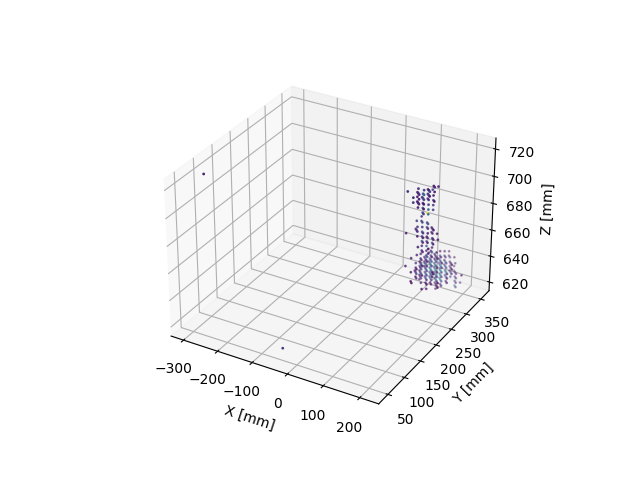

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

event = sophronia[sophronia.event == 128999]

# 2. Use ax.scatter and explicitly label your arguments
# x, y, z are the first three positional arguments
ax.scatter(event.X, event.Y, event.Z, c=event.Ec, s=1)

ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_zlabel('Z [mm]')

plt.show()

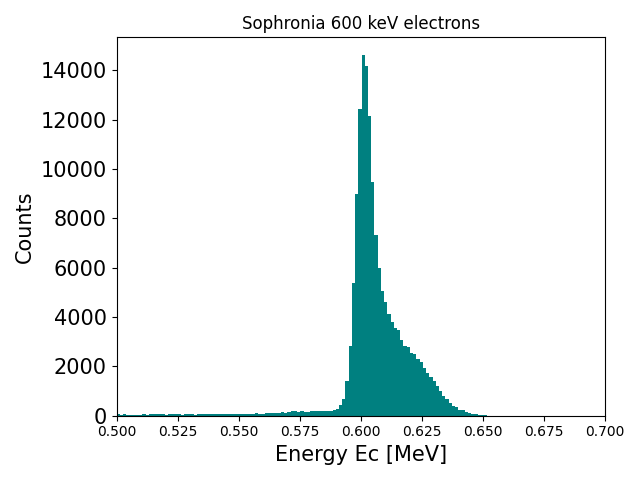

In [41]:
event_energies = sophronia.groupby("event").Ec.sum()

plt.figure()
plt.hist(event_energies, bins = 500, color = "Teal");
plt.xlabel("Energy Ec [MeV]", fontsize = 15)
plt.ylabel("Counts", fontsize = 15)
# plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlim(0.5,0.7)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()


In [61]:
sophronia_avg = sophronia.groupby('event').agg({
    'X': 'mean',
    'Y': 'mean',
    'Z': 'mean',
    'Ec': 'sum',
    'E' : 'sum',
    "Q" : 'sum'
}).reset_index()

# 2. Calculate the radial position (R) of the event center
# Using the averaged X and Y coordinates
sophronia_avg['radius'] = np.sqrt(sophronia_avg['X']**2 + sophronia_avg['Y']**2)

sophronia_avg = sophronia_avg[sophronia_avg.Ec > 0.5]


display(sophronia_avg)

,event,X,Y,Z,Ec,E,Q,radius
1,201,328.151984,338.668122,260.107062,0.500132,94023.913541,4029.449291,471.571650
2,202,71.613447,-315.732386,851.419129,0.608296,145740.762950,4088.231870,323.752105
3,203,6.558456,-257.664154,605.609322,0.598718,147866.793956,4084.289846,257.747609
4,204,-61.091667,-455.475654,199.835507,0.619789,110348.080530,4560.347816,459.554418
5,205,-81.881960,133.277747,1106.423555,0.600789,149937.603986,3527.362320,156.421268
...,...,...,...,...,...,...,...,...
178035,200195,-293.802138,-1.375000,458.120468,0.603826,149313.540077,3703.246365,293.805355
178036,200196,-226.289516,242.860323,808.895470,0.610075,144057.578275,3742.840588,331.945901
178037,200197,27.193108,244.146892,40.798217,0.596445,150335.582623,4375.072455,245.656610
178038,200198,-224.379433,331.149877,186.116352,0.604347,140883.445533,4770.028992,400.007964


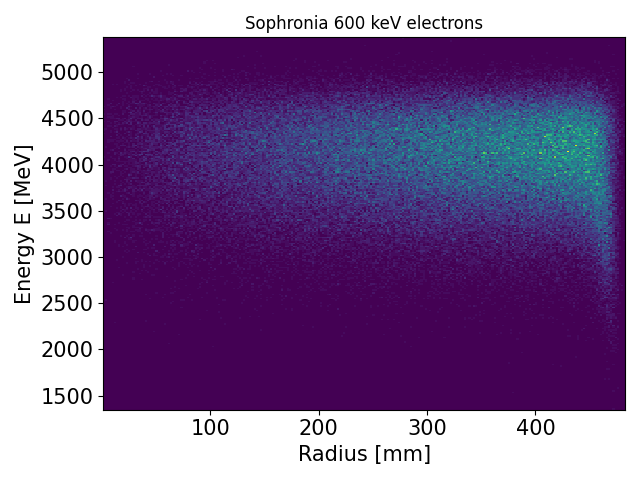

In [62]:
plt.figure()

plt.hist2d(sophronia_avg.radius, sophronia_avg.Q, bins= 250);

plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("Energy E [MeV]", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()




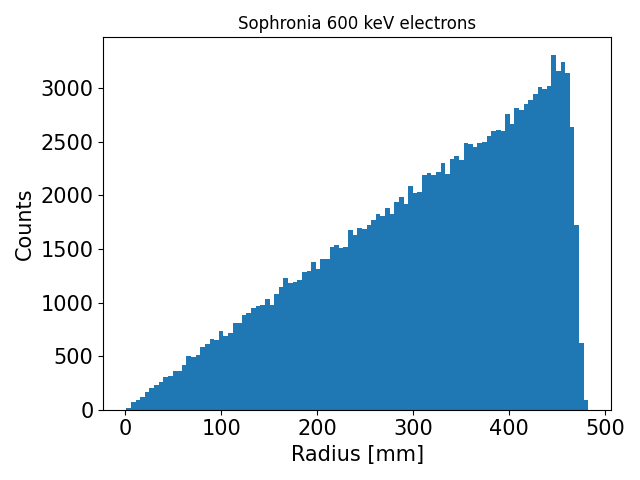

In [57]:
plt.figure()

plt.hist(sophronia_avg.radius, bins= 100);

plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("Counts", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

In [44]:
# Per sample, load time is: 
def LoadFilesMC(filepath):
    
    files = glob.glob(filepath)
    
    
    hits = []
    for i, f in enumerate(files):
        if i %500 ==0:
            print(f"{i} /", len(files))
        hits_ = pd.read_hdf(f, "MC/hits")
        hits.append(hits_)    
    return pd.concat(hits)

mchits = LoadFilesMC("/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5")
display(mchits)

0 / 913
500 / 913


,event_id,particle_id,hit_id,x,y,z,time,energy,label
0,67600,1,0,-270.842743,263.304138,1092.262573,0.003740,0.002031,ACTIVE
1,67600,1,1,-270.668457,263.095154,1093.220703,0.007483,0.000454,ACTIVE
2,67600,1,2,-270.551727,263.030518,1094.210693,0.011238,0.001209,ACTIVE
3,67600,1,3,-270.425140,262.948059,1095.197510,0.014992,0.001713,ACTIVE
4,67600,1,4,-270.353821,262.644653,1096.144287,0.018741,0.000343,ACTIVE
...,...,...,...,...,...,...,...,...,...
68252,128999,1,218,161.682602,310.854492,638.890320,0.690711,0.000567,ACTIVE
68253,128999,1,219,161.679199,310.849731,638.890320,0.690852,0.000294,ACTIVE
68254,128999,1,220,161.674866,310.848114,638.886780,0.690998,0.000025,ACTIVE
68255,128999,1,221,161.671494,310.846039,638.883484,0.691126,0.003644,ACTIVE


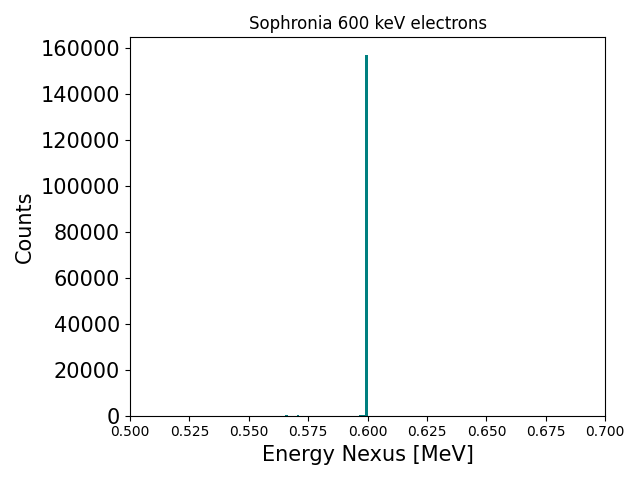

In [45]:
event_energies = mchits.groupby("event_id").energy.sum()

plt.figure()
plt.hist(event_energies, bins = 500, color = "Teal");
plt.xlabel("Energy Nexus [MeV]", fontsize = 15)
plt.ylabel("Counts", fontsize = 15)
# plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlim(0.5,0.7)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

In [47]:
mchits_avg = mchits.groupby('event_id').agg({
    'x': 'mean',
    'y': 'mean',
    'z': 'mean',
    'energy': 'sum'
}).reset_index()

# 2. Calculate the radial position (R) of the event center
# Using the averaged X and Y coordinates
mchits_avg['radius'] = np.sqrt(mchits_avg['x']**2 + mchits_avg['y']**2)

mchits_avg = mchits_avg[mchits_avg.energy > 0.5]


display(mchits_avg)

,event_id,x,y,z,energy,radius
1,201,330.681366,353.097321,253.532349,0.6,483.764282
2,202,68.361977,-319.765564,849.861755,0.6,326.991394
3,203,6.169563,-257.416626,606.559875,0.6,257.490540
4,204,-63.555077,-458.398132,198.440628,0.6,462.782990
5,205,-76.837593,132.324051,1102.449219,0.6,153.015259
...,...,...,...,...,...,...
178637,200195,-297.716156,2.813762,464.478180,0.6,297.729431
178638,200196,-226.027405,246.288940,808.301514,0.6,334.285248
178639,200197,30.265785,244.165756,36.296093,0.6,246.034424
178640,200198,-221.963379,326.863220,186.351227,0.6,395.104187


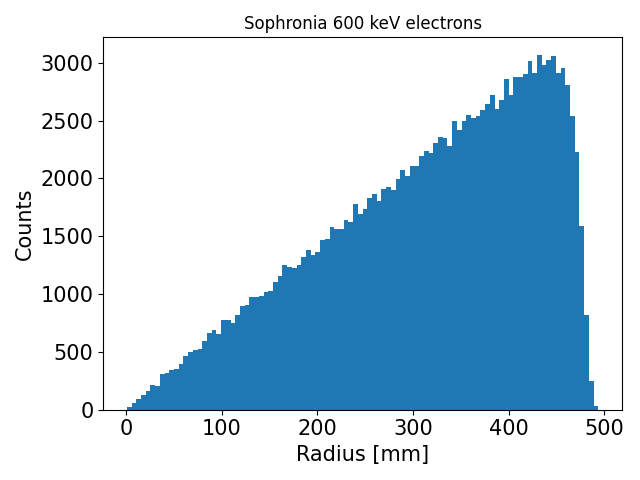

In [52]:
plt.figure()

plt.hist(mchits_avg.radius, bins= 100);

plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("Counts", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()


